In [1]:
import os
import pickle
import joblib
import math
import hdbscan
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import Birch, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch


In [2]:
nnary_df = pd.read_csv("./output/nnary_features.csv").set_index("filename")
nnary_df

,uni_1_count,uni_1_total_area,uni_1_avg_x,uni_1_avg_y,uni_2_count,uni_2_total_area,uni_2_avg_x,uni_2_avg_y,uni_3_count,uni_3_total_area,...,tri_5_7_8_count,tri_5_7_8_area_ratio_ij,tri_5_7_8_area_ratio_jk,tri_5_7_8_avg_x,tri_5_7_8_avg_y,tri_6_7_8_count,tri_6_7_8_area_ratio_ij,tri_6_7_8_area_ratio_jk,tri_6_7_8_avg_x,tri_6_7_8_avg_y
filename,,,,,,,,,,,,,,,,,,,,,
40795.png,2.0,3396.0,-38.604240,53.561837,1.0,2542.0,72.000000,60.500000,1,6998.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60259.png,NaN,NaN,NaN,NaN,1.0,6864.0,-46.000000,4.000000,1,3596.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45409.png,2.0,4462.0,-2.314433,115.000000,1.0,2156.0,-31.000000,4.500000,1,5624.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22733.png,1.0,1855.0,43.500000,80.500000,1.0,2560.0,87.000000,65.000000,1,6431.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25886.png,1.0,1591.0,72.500000,46.500000,1.0,2433.5,73.436340,99.513321,1,6373.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26753.png,1.0,2135.5,39.887224,53.269570,1.0,2359.5,18.394646,150.781027,1,6447.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42387.png,1.0,2378.0,-76.000000,37.500000,1.0,2575.0,-101.982524,85.307702,1,8847.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19466.png,2.0,3132.0,49.873563,51.637931,NaN,NaN,NaN,NaN,1,6677.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
nnary_df = nnary_df.fillna(0)

nnary_df = nnary_df.loc[:, ~(nnary_df == 0).all()]

In [4]:
nnary_sans78_df = nnary_df.loc[:, ~nnary_df.columns.str.contains(r'7|8')]

In [18]:

# Build a feature dictionary for each floorplan
feature_rows = []

for plan in graphs:
    feature_dict = {'filename': plan['filename']}
    
    # Group rooms by type
    rooms_by_type = {rtype: [] for rtype in all_types}
    for room in plan['rooms']:
        rooms_by_type[room['type']].append(room)
    
    # For each room type, take up to 3 rooms
    for room_type in all_types:
        selected_rooms = rooms_by_type[room_type][:3]
        # Fill in features for each of the up to 3 rooms
        for i in range(3):
            prefix = f"{room_type}_{i+1}"
            if i < len(selected_rooms):
                room = selected_rooms[i]
                feature_dict[f"{prefix}_x"] = room['centroid'][0]
                feature_dict[f"{prefix}_y"] = room['centroid'][1]
                feature_dict[f"{prefix}_area"] = room['area']
            else:
                # If room doesn't exist, fill with 0
                feature_dict[f"{prefix}_x"] = 0.0
                feature_dict[f"{prefix}_y"] = 0.0
                feature_dict[f"{prefix}_area"] = 0.0
    
    feature_rows.append(feature_dict)

# Create DataFrame
df = pd.DataFrame(feature_rows)

# Display the DataFrame to the user
df.set_index('filename', inplace=True)

df

NameError: name 'graphs' is not defined

In [5]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(nnary_sans78_df),
    index=nnary_sans78_df.index,
    columns=nnary_sans78_df.columns
)

X = df_scaled.values
X

array([[ 9.17179551e-01,  3.70101426e-01, -7.39991613e-01, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       [-2.62673591e+00, -2.53616291e+00, -2.31607854e-02, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       [ 9.17179551e-01,  1.28237404e+00, -6.61368136e-02, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       ...,
       [ 9.17179551e-01,  1.44172750e-01,  9.02926798e-01, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       [ 9.17179551e-01,  1.05516167e+00, -3.88141816e-01, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       [ 9.17179551e-01,  1.24300768e+00, -1.93896695e+00, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01]])

In [6]:
num_data = 40000

In [8]:

linked = sch.linkage(X[:num_data], method='ward')

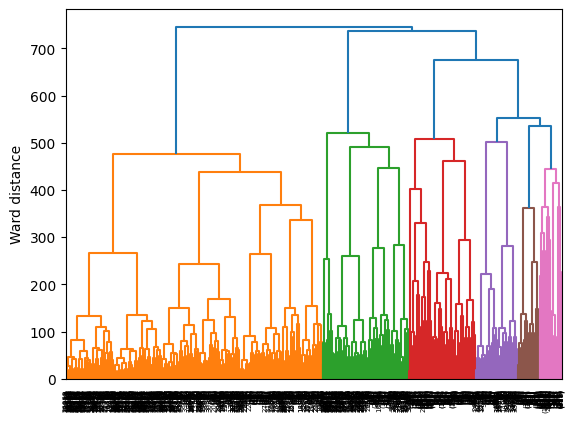

In [9]:
sch.dendrogram(linked, truncate_mode='level', p=10)
plt.ylabel("Ward distance")
plt.show()

In [10]:
clusterer = AgglomerativeClustering(n_clusters=20, linkage='ward')
labels = clusterer.fit_predict(X[:num_data])

In [11]:
# cnt = Counter(list(labels) + list(labels_rest))
cnt = Counter(list(labels))
for lbl, count in sorted(cnt.items()):
    if lbl == -1:
        print(f"  Noise points: {count}")
    else:
        print(f"  Cluster {lbl:>2}: {count} plans")

  Cluster  0: 3484 plans
  Cluster  1: 4242 plans
  Cluster  2: 809 plans
  Cluster  3: 7397 plans
  Cluster  4: 1475 plans
  Cluster  5: 359 plans
  Cluster  6: 31 plans
  Cluster  7: 521 plans
  Cluster  8: 8514 plans
  Cluster  9: 366 plans
  Cluster 10: 516 plans
  Cluster 11: 2722 plans
  Cluster 12: 1973 plans
  Cluster 13: 2590 plans
  Cluster 14: 1079 plans
  Cluster 15: 1273 plans
  Cluster 16: 2 plans
  Cluster 17: 1104 plans
  Cluster 18: 978 plans
  Cluster 19: 565 plans


In [12]:
X[:num_data, :].shape

(40000, 184)

In [17]:
k_final = 20
num_data = 40000
cluster_centroids_16 = np.zeros((k_final, X.shape[1]), dtype=float)
X_first_n = X[:num_data]
for k in range(k_final):
    members = (labels == k)
    if np.any(members):
        cluster_centroids_16[k] = X_first_n[members].mean(axis=0)
    else:
        cluster_centroids_16[k] = 0.0

In [18]:
colnames = nnary_sans78_df.columns

In [19]:
topn = 20
top_features_per_cluster = {}
for k in range(k_final):
    centroid_vals = cluster_centroids_16[k]
    top_indices = np.argsort(centroid_vals)[-topn:][::-1]
    top_features = [(colnames[idx], centroid_vals[idx]) for idx in top_indices]
    top_features_per_cluster[k] = top_features

    print(f"\nCluster {k} — top {topn} features (feature_name, z‐score):")
    for feat_name, zval in top_features:
        print(f"  {feat_name:30s}  {zval:6.2f}")


Cluster 0 — top 20 features (feature_name, z‐score):
  tri_1_2_4_count                   2.68
  tri_1_2_4_area_ratio_ij           2.62
  tri_1_2_4_area_ratio_jk           2.52
  tri_1_2_4_avg_y                   2.13
  bi_1_4_area_ratio                 1.31
  bi_1_4_count                      1.26
  tri_1_2_3_area_ratio_jk           1.15
  bi_1_4_avg_y                      1.06
  tri_1_2_3_area_ratio_ij           1.04
  bi_1_2_area_ratio                 1.04
  bi_2_4_area_ratio                 1.02
  bi_2_4_count                      0.91
  tri_1_2_3_count                   0.87
  bi_1_2_count                      0.87
  bi_1_3_area_ratio                 0.71
  tri_1_2_3_avg_y                   0.64
  bi_1_2_avg_y                      0.56
  bi_2_4_avg_y                      0.49
  uni_1_total_area                  0.43
  bi_2_3_area_ratio                 0.40

Cluster 1 — top 20 features (feature_name, z‐score):
  tri_3_5_6_area_ratio_jk           0.78
  bi_5_6_area_ratio            

In [20]:
N = 20
under_features_per_cluster = {}

for k in range(k_final):
    centroid_vals = cluster_centroids_16[k]

    neg_indices = np.argsort(centroid_vals)[:N]
    neg_feats = [(colnames[idx], centroid_vals[idx]) for idx in neg_indices]
    under_features_per_cluster[k] = neg_feats

    print(f"\nCluster {k} — top {N} under‐represented features (name, z‐score):")
    for feat_name, zval in neg_feats:
        print(f"  {feat_name:30s} {zval:6.2f}")


Cluster 0 — top 20 under‐represented features (name, z‐score):
  bi_3_4_count                    -1.06
  bi_3_4_avg_y                    -0.87
  bi_3_4_area_ratio               -0.82
  tri_2_3_4_count                 -0.64
  tri_2_3_4_area_ratio_ij         -0.62
  tri_2_3_4_avg_y                 -0.58
  bi_4_6_count                    -0.52
  tri_2_3_4_area_ratio_jk         -0.52
  bi_1_5_count                    -0.51
  bi_2_5_avg_y                    -0.48
  tri_1_3_5_count                 -0.47
  tri_1_3_5_area_ratio_jk         -0.47
  uni_2_avg_y                     -0.45
  bi_1_5_avg_y                    -0.44
  tri_1_3_5_avg_y                 -0.43
  bi_4_6_area_ratio               -0.43
  uni_3_total_area                -0.42
  tri_1_3_4_count                 -0.40
  tri_1_3_4_area_ratio_ij         -0.38
  tri_2_3_5_avg_y                 -0.38

Cluster 1 — top 20 under‐represented features (name, z‐score):
  bi_3_5_avg_x                    -0.68
  tri_2_3_5_avg_x               

In [22]:
filenames = nnary_sans78_df.index

In [23]:
cosim_matrix = cosine_similarity(X, cluster_centroids_16) 
cosim_matrix.shape

cosim_colnames = [f"cos_sim_{k}" for k in range(k_final)]
df_cosim = pd.DataFrame(cosim_matrix, index=filenames, columns=cosim_colnames)

df_features = pd.DataFrame(X, index=filenames, columns=colnames)

In [24]:
df_result = pd.concat([df_cosim, df_features, ], axis=1)[:num_data]
df_result['cluster'] = labels

In [25]:
df_result = df_result[[df_result.columns[-1]] + list(df_result.columns[:-1])]

In [26]:
df_result.to_csv("clustering_result_nnary.csv")

In [27]:
df_result[:1000].to_csv("clustering_result_nnary_first1000.csv")